# Policy Iteration — FrozenLake-v1

This notebook solves the **FrozenLake-v1** environment from Gymnasium using **Policy Iteration**, a dynamic programming algorithm that alternates between evaluating a policy and improving it until the policy stabilises.

## Environment

FrozenLake is a 4×4 grid where the agent must navigate from the top-left start (S) to the bottom-right goal (G) while avoiding holes (H). We use `is_slippery=False` so transitions are deterministic.

```
S F F F
F H F H
F F F H
H F F G
```

| | |
|---|---|
| **States** | 16 (one per grid cell) |
| **Actions** | 4 — Left (0), Down (1), Right (2), Up (3) |
| **Reward** | +1 on reaching G, 0 otherwise |
| **Terminal states** | G and all H cells |

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

## Algorithm

Policy Iteration finds the optimal policy by repeating two phases until the policy no longer changes:

**Phase 1 — Policy Evaluation:** compute the value function for the *current* policy by iterating the **Bellman expectation equation** until convergence:

$$V^\pi(s) \leftarrow \sum_{s'} P(s'|s,\pi(s))\,[r(s,\pi(s),s') + \gamma \cdot V(s')]$$

Note that only the action dictated by the current policy $\pi(s)$ is considered — there is no max over actions here.

**Phase 2 — Policy Improvement:** update the policy greedily using the converged Value Function:

$$\pi(s) \leftarrow \arg\max_a \sum_{s'} P(s'|s,a)\,[r(s,a,s') + \gamma \cdot V^\pi(s')]$$

The outer loop repeats until the policy is **stable** — no state changed its action.

| Symbol | Role |
|--------|------|
| $\gamma$ | Discount factor — balances immediate vs. future reward |
| $\epsilon$ | Convergence threshold for policy evaluation |
| $P(s'\|s,a)$ | Transition probabilities, accessed via `env.unwrapped.P` |

## Policy Iteration vs Value Iteration

The key difference from Value Iteration is in Phase 1. Value Iteration uses the Bellman *optimality* equation (max over all actions); Policy Iteration uses the Bellman *expectation* equation (fixed action from the current policy). As a result, Policy Iteration typically converges in fewer outer iterations but each iteration is more expensive.

## Implementation

`policy_iteration(env, gamma, epsilon)` runs the two phases inside an outer loop:

1. **Policy Evaluation** (inner `while True`) — sweeps all states applying the Bellman expectation update until $\delta < \epsilon$.
2. **Policy Improvement** — sweeps all states, recomputes Q-values for every action, updates the policy greedily, and flags if anything changed.
3. If the policy was stable after improvement, the outer loop exits.

In [2]:
def policy_iteration(env, gamma=0.99, epsilon=1e-6):
    n_states = env.observation_space.n                              # number of states in the environment
    n_actions = env.action_space.n                                  # number of actions in the environment
    V = np.zeros(n_states)                                          # Value Function initialized to zero for each state
    policy = np.zeros(n_states, dtype=int)                          # Policy initialized to action 0 for each state
    iteration = 0

    while True:
        # --- Phase 1: Policy Evaluation ---
        while True:
            delta = 0                                               # delta initialized to zero
            for state in range(n_states):                           # for each state:
                v = V[state]                                        # 1. save current value of Value Function
                V[state] = sum(
                    prob * (reward + gamma * V[next_state])
                    for prob, next_state, reward, done
                    in env.unwrapped.P[state][policy[state]]        # 2. update V(s) using Bellman expectation equation
                )                                                   #    under the current policy action
                delta = max(delta, abs(v - V[state]))               # track largest change across all states
            
            iteration += 1
            if delta < epsilon:                                     # exit when Value Function has converged
                break
        
        # --- Phase 2: Policy Improvement ---
        policy_stable = True                                        # assume policy won't change
        for state in range(n_states):                               # for each state:
            b = policy[state]                                       # 1. save current policy action
            q_values = np.zeros(n_actions)
            for action in range(n_actions):                         # 2. compute Q-values for all actions
                for prob, next_state, reward, done in env.unwrapped.P[state][action]:
                    q_values[action] += prob * (reward + gamma * V[next_state])
            policy[state] = np.argmax(q_values)                     # 3. update policy greedily
            if b != policy[state]:                                  # 4. if any action changed, policy is not stable yet
                policy_stable = False
        
        if policy_stable:                                           # exit when policy no longer changes
            break
    
    return V, policy, iteration

## Environment Setup

Create the FrozenLake environment and render a snapshot of the grid.

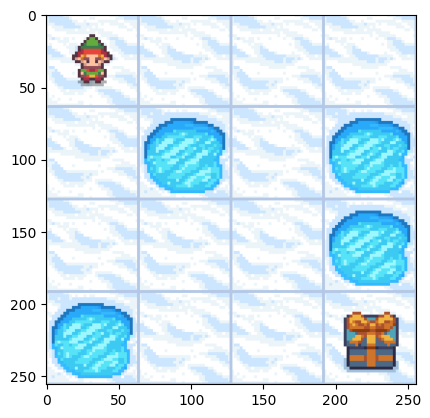

In [3]:
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
env.reset()
frame = env.render()
plt.imshow(frame);

## Results

Run Policy Iteration and print the converged value function and the derived optimal policy.

The **value function** shows the expected discounted return from each cell under the optimal policy. The **policy** gives the best action to take in each state (0=Left, 1=Down, 2=Right, 3=Up).

In [9]:
gamma = 0.99
epsilon = 1e-6

V, policy, iterations = policy_iteration(env, gamma, epsilon)

print("Optimal Value Function:")
print(V.reshape(4, 4))
print("\nOptimal Policy (0=Left, 1=Down, 2=Right, 3=Up):")
print(policy.reshape(4, 4))
print("\nNumber of iterations: ", iterations)

Optimal Value Function:
[[0.95099005 0.96059601 0.970299   0.96059601]
 [0.96059601 0.         0.9801     0.        ]
 [0.970299   0.9801     0.99       0.        ]
 [0.         0.99       1.         0.        ]]

Optimal Policy (0=Left, 1=Down, 2=Right, 3=Up):
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]

Number of iterations:  13
